<a href="https://colab.research.google.com/github/lattytytyty-web/Ge337-PROGRAMMING-DEVELOPMENT-FOR-GEOSPATIAL-DATA-ANALYSIS/blob/main/Lab_4_%E0%B8%A3%E0%B8%B1%E0%B8%95%E0%B8%95%E0%B8%B4%E0%B8%A2%E0%B8%B2_6606614813.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 4: การพัฒนาแบบจำลอง Machine Learning สำหรับการจำแนกพื้นที่ป่าด้วยข้อมูลภาพถ่ายดาวเทียม

In [8]:
!pip install rasterio geopandas scikit-learn matplotlib

import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ======================
# 1. โหลดข้อมูล
# ======================
csv_path = "/content/ayutthaya_samples.csv"
tif_path = "/content/ayutthaya_raw_SAFE.tif"

df = pd.read_csv(csv_path)
df = df.dropna()

print(df.head())

# ======================
# 2. เตรียม features
# ======================
X = df[['B2','B3','B4','B8','NDVI']]
y = df['class']

# ======================
# 3. train/test split
# ======================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# ======================
# 4. train model
# ======================
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# ======================
# 5. evaluate
# ======================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))

   system:index      B2      B3      B4      B8      NDVI  class  \
0             2  3174.0  3556.0  3636.0  3287.0 -0.050412      1   
1             5  1916.0  2214.0  2876.0  3656.0  0.119412      1   
2             6  1480.0  1670.0  1770.0  3264.0  0.296782      0   
3             8  1942.0  2006.0  2050.0  3078.0  0.200468      0   
4            12  1360.0  1552.0  1387.0  1245.0 -0.053951      2   

                                                .geo  
0  {"type":"Point","coordinates":[100.61023984004...  
1  {"type":"Point","coordinates":[100.71198403873...  
2  {"type":"Point","coordinates":[100.36594754836...  
3  {"type":"Point","coordinates":[100.73501028142...  
4  {"type":"Point","coordinates":[100.54763068940...  
Accuracy: 0.8850574712643678
Confusion Matrix:
 [[55  2  1]
 [ 5 16  0]
 [ 2  0  6]]
Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92        58
           1       0.89      0.76      0.82        21
    

In [9]:
import rasterio

src = rasterio.open("ayutthaya_raw_image.tif")
print(src.count)  # ต้องได้ 5 bands

5


In [12]:
import rasterio

src = rasterio.open("ayutthaya_raw_SAFE.tif")
print(src.count)

B2 = src.read(1)  # ต้องไม่ error แล้ว

5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


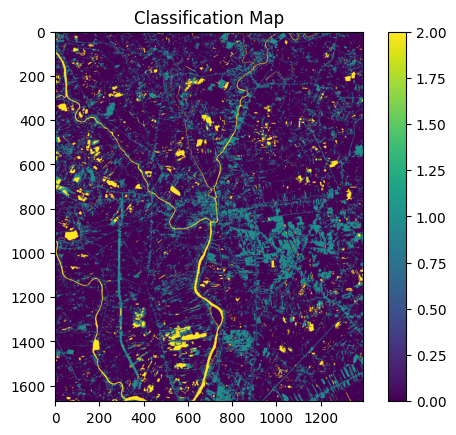

In [11]:
# ======================
# 6. โหลดภาพ raster
# ======================
src = rasterio.open(tif_path)

B2 = src.read(1)
B3 = src.read(2)
B4 = src.read(3)
B8 = src.read(4)

# คำนวณ NDVI
ndvi = (B8 - B4) / (B8 + B4 + 1e-10)

# ======================
# 7. เตรียมข้อมูลทั้งภาพ
# ======================
rows, cols = B2.shape

stacked = np.stack([B2, B3, B4, B8, ndvi], axis=-1)
flat_pixels = stacked.reshape(-1, 5)

# ======================
# 8. predict ทั้งภาพ
# ======================
pred = model.predict(flat_pixels)
classified = pred.reshape(rows, cols)

# ======================
# 9. แสดงผล
# ======================
plt.imshow(classified, cmap='viridis')
plt.title("Classification Map")
plt.colorbar()
plt.show()

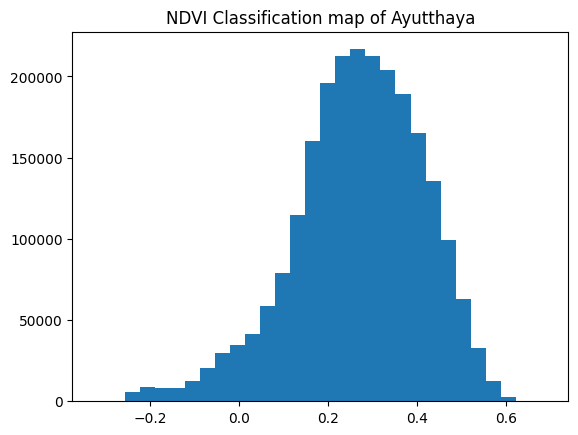

In [16]:
plt.hist(ndvi.flatten(), bins=30)
plt.title("NDVI Classification map of Ayutthaya")
plt.show()

# **คำถามท้าย Lab**

1. ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?

**ตอบ** เพราะ Feature ที่ดีช่วยให้โมเดลแยกข้อมูลได้แม่นขึ้น ถ้าเลือกไม่ดี โมเดลจะสับสนและแม่นยำน้อยลง

2. เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้

**ตอบ** Random Forest ใช้ง่ายและเหมาะกับข้อมูลเยอะ ส่วน SVM แม่นแต่ต้องปรับค่ามากกว่า งานนี้เลยใช้ Random Forest จะสะดวกกว่า

3. การใช้ NDVI เพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?

**ตอบ** ไม่พอ เพราะ NDVI บอกแค่ความเขียว แยกเมืองหรือน้ำไม่ค่อยได้ ต้องใช้ band อื่นช่วยด้วย

4. หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?

**ตอบ** เพิ่มข้อมูล training, เพิ่ม feature, ปรับค่าของโมเดล หรือใช้ข้อมูลที่สะอาดขึ้น

5. ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?

**ตอบ** ข้อมูลไม่พอ, pixel คล้ายกัน,
มีเมฆหรือ noise และเลือก feature ไม่ดี
